<a href="https://colab.research.google.com/github/eswaranpandian15-arch/DLV/blob/main/DLV_CODE_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Implementation of Basic Image Processing Operations Including Feature Representation and Feature Extraction

## Resources

Image processing complete. Displaying results using matplotlib...


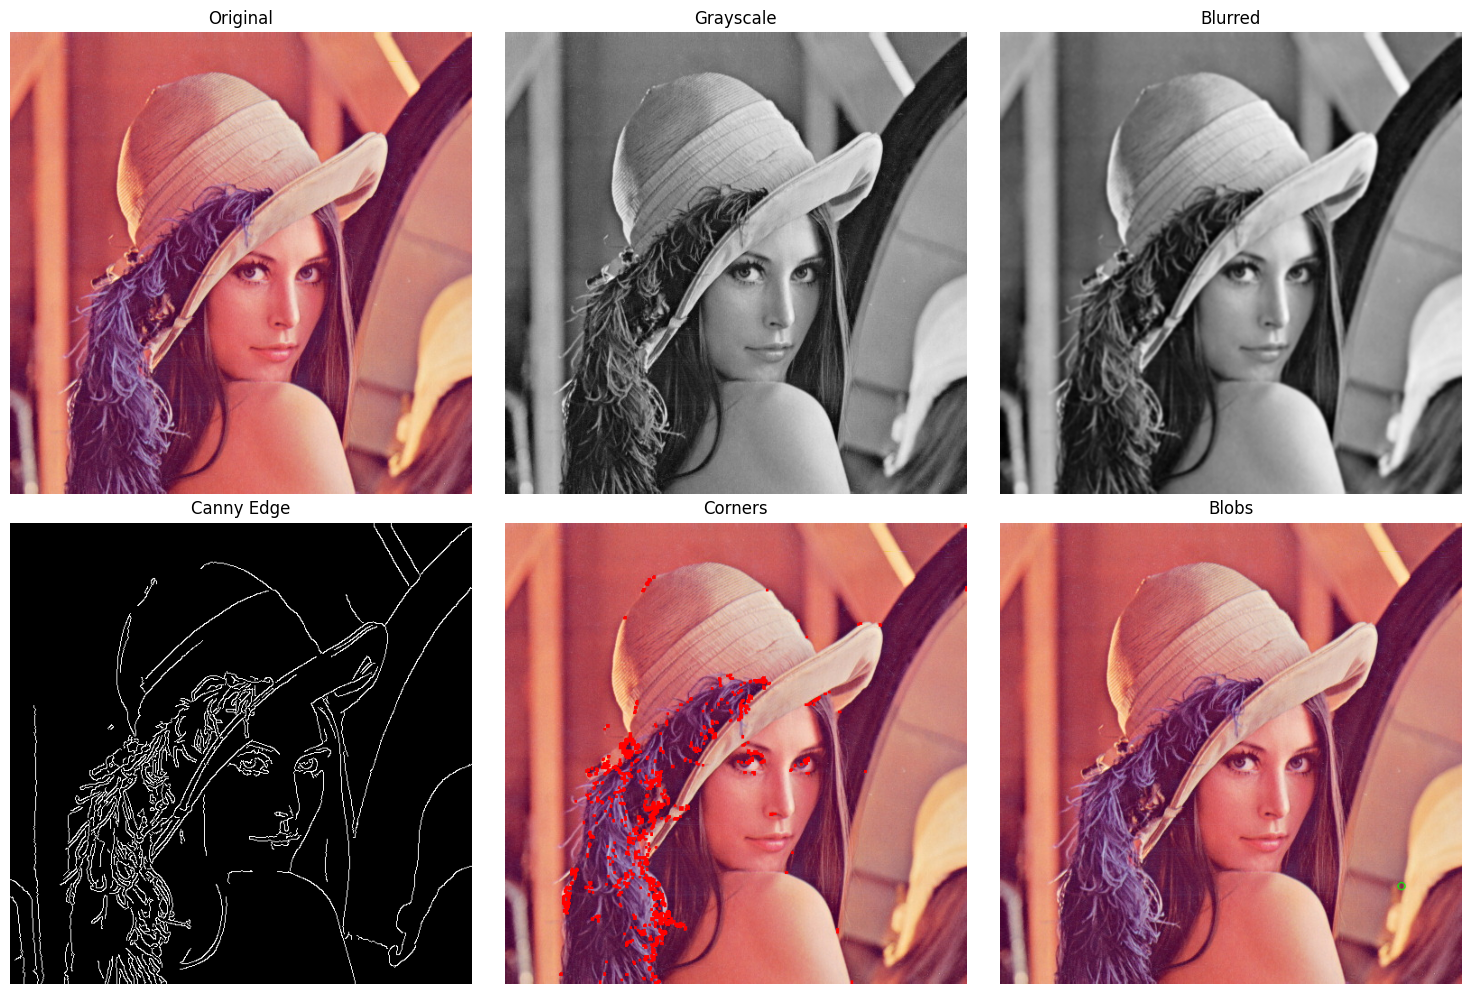

In [7]:
import cv2
import numpy as np
import urllib.request
import matplotlib.pyplot as plt # Added matplotlib import

# Download a sample image if it doesn't exist
# Changed image_url to a more reliable source
image_url = 'https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg'
image_filename = 'sample.jpg'

try:
    with open(image_filename, 'rb') as f:
        pass # File exists, do nothing
except FileNotFoundError:
    print(f"Downloading {image_filename}...")
    try:
        urllib.request.urlretrieve(image_url, image_filename)
        print("Download complete.")
    except urllib.error.HTTPError as e:
        print(f"Error downloading image: {e}. Please check the URL or try a different image.")
        # Exit or handle the error gracefully if download fails
        exit()

img = cv2.imread(image_filename)

# Check if image was loaded successfully
if img is None:
    print(f"Error: Could not load image from '{image_filename}'. Please ensure the file exists and is a valid image.")
else:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blur, 50, 150)

    # Harris Corner Detection
    # The input image for cornerHarris must be float32
    corners = cv2.cornerHarris(np.float32(gray), 2, 3, 0.04)
    # Result is dilated for marking the corners, not important
    corners_dilated = cv2.dilate(corners, None)
    img_corners = img.copy()
    # Threshold for an optimal value, it may vary depending on the image
    img_corners[corners_dilated > 0.01 * corners_dilated.max()] = [0, 0, 255] # Mark corners in red

    # Simple Blob Detector
    detector = cv2.SimpleBlobDetector_create()
    keypoints = detector.detect(gray)
    img_blobs = cv2.drawKeypoints(img, keypoints, np.array([]), (0, 255, 0), cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

    # Display images
    # Note: cv2.imshow does not work directly in Colab notebooks.
    # You would typically use matplotlib for displaying images here.
    # For this example, I will comment out cv2.imshow and suggest using matplotlib.
    print("Image processing complete. Displaying results using matplotlib...")
    plt.figure(figsize=(15, 10))

    plt.subplot(2, 3, 1), plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title('Original'), plt.axis('off')

    plt.subplot(2, 3, 2), plt.imshow(gray, cmap='gray')
    plt.title('Grayscale'), plt.axis('off')

    plt.subplot(2, 3, 3), plt.imshow(blur, cmap='gray')
    plt.title('Blurred'), plt.axis('off')

    plt.subplot(2, 3, 4), plt.imshow(edges, cmap='gray')
    plt.title('Canny Edge'), plt.axis('off')

    plt.subplot(2, 3, 5), plt.imshow(cv2.cvtColor(img_corners, cv2.COLOR_BGR2RGB))
    plt.title('Corners'), plt.axis('off')

    plt.subplot(2, 3, 6), plt.imshow(cv2.cvtColor(img_blobs, cv2.COLOR_BGR2RGB))
    plt.title('Blobs'), plt.axis('off')

    plt.tight_layout()
    plt.show()

    # cv2.imshow("Original", img)
    # cv2.imshow("Grayscale", gray)
    # cv2.imshow("Blurred", blur)
    # cv2.imshow("Canny Edge", edges)
    # cv2.imshow("Corners", img_corners)
    # cv2.imshow("Blobs", img_blobs)
    # cv2.waitKey(0)
    # cv2.destroyAllWindows()



